In [0]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
import seaborn as sns
import matplotlib.pyplot as plt

def generate_complex_banking_data(n_users=15000):
    np.random.seed(101) 
    
    # 1. Base Population Features
    data = pd.DataFrame({
        'user_id': range(1, n_users + 1),
        'group': np.random.choice(['control', 'treatment'], size=n_users),
        'credit_score': np.random.normal(660, 85, n_users).clip(300, 850),
        'age': np.random.randint(18, 75, n_users),
        'income_bracket': np.random.choice(['Low', 'Medium', 'High'], size=n_users, p=[0.3, 0.5, 0.2])
    })

    # 2. Logic for "Messy" Conversion (Simulating Segmented UX Impact)
    def calculate_conversion(row):
        prob = 0.03 # Base 3% conversion rate
        
        # Financial Profile influence
        if row['credit_score'] > 700: prob += 0.04
        if row['credit_score'] < 600: prob -= 0.01
        
        # THE TWIST: Segmented impact (Simulating tech-adoption gaps)
        if row['group'] == 'treatment':
            if row['age'] < 35:
                prob += 0.015  # Mobile-first win
            elif row['age'] > 55:
                prob -= 0.012  # UX Friction for seniors
            else:
                prob += 0.002  
        
        # Add 'Environmental Noise' to simulate real-world variance
        prob += np.random.normal(0, 0.008)
        
        return np.random.binomial(1, max(0.005, min(prob, 0.95)))

    data['converted'] = data.apply(calculate_conversion, axis=1)
    return data

df_banking = generate_complex_banking_data()

In [0]:
# Statistical Engine Functions:
def run_z_test(df):
    results = df.groupby('group')['converted'].agg(['sum', 'count'])
    # Reversing order to get [treatment, control]
    counts = results['sum'].values[::-1]
    nobs = results['count'].values[::-1]
    z_stat, p_val = proportions_ztest(counts, nobs)
    return {"stat": z_stat, "p_value": p_val}

def run_bootstrap(df, iterations=5000):
    diffs = []
    control = df[df['group'] == 'control']['converted'].values
    treatment = df[df['group'] == 'treatment']['converted'].values
    for _ in range(iterations):
        t_mean = np.random.choice(treatment, len(treatment), replace=True).mean()
        c_mean = np.random.choice(control, len(control), replace=True).mean()
        diffs.append(t_mean - c_mean)
    p_val = np.mean(np.array(diffs) <= 0)
    return {"p_value": p_val, "samples": diffs}

def run_bayesian(df):
    results = df.groupby('group')['converted'].agg(['sum', 'count'])
    # Beta-Binomial Conjugate Prior (Flat Prior: Alpha=1, Beta=1)
    a_t, b_t = 1 + results.loc['treatment', 'sum'], 1 + (results.loc['treatment', 'count'] - results.loc['treatment', 'sum'])
    a_c, b_c = 1 + results.loc['control', 'sum'], 1 + (results.loc['control', 'count'] - results.loc['control', 'sum'])
    
    samples_t = np.random.beta(a_t, b_t, 10000)
    samples_c = np.random.beta(a_c, b_c, 10000)
    prob_winner = np.mean(samples_t > samples_c)
    return {"prob_winner": prob_winner, "samples_t": samples_t, "samples_c": samples_c}

# Execute Engine
z_res = run_z_test(df_banking)
boot_res = run_bootstrap(df_banking)
bay_res = run_bayesian(df_banking)

In [0]:
# Strategic Reporting & Segmentation
def run_segmented_report(df):
    df['age_segment'] = pd.cut(df['age'], bins=[0, 35, 55, 100], labels=['Young', 'Mid', 'Senior'])
    report = df.groupby(['age_segment', 'group'])['converted'].agg(['mean', 'count']).unstack()
    report['Lift (%)'] = (report['mean']['treatment'] - report['mean']['control']) / report['mean']['control'] * 100
    
    print("\n" + "="*45)
    print("STRATEGIC SEGMENTATION REPORT")
    print("="*45)
    print(report[['Lift (%)']])
    print("="*45)
    if any(report['Lift (%)'] < 0):
        print("⚠️ INSIGHT: Adverse impact detected in specific segments.")

run_segmented_report(df_banking)


STRATEGIC SEGMENTATION REPORT
              Lift (%)
group                 
age_segment           
Young        17.223911
Mid          21.639487
Senior      -47.043084
⚠️ INSIGHT: Adverse impact detected in specific segments.


/home/spark-0f9b4a6b-14f9-49fe-a578-54/.ipykernel/2531320/command-8498872419432667-3503796774:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  report = df.groupby(['age_segment', 'group'])['converted'].agg(['mean', 'count']).unstack()


/databricks/python/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/databricks/python/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/databricks/python/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/databricks/python/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When

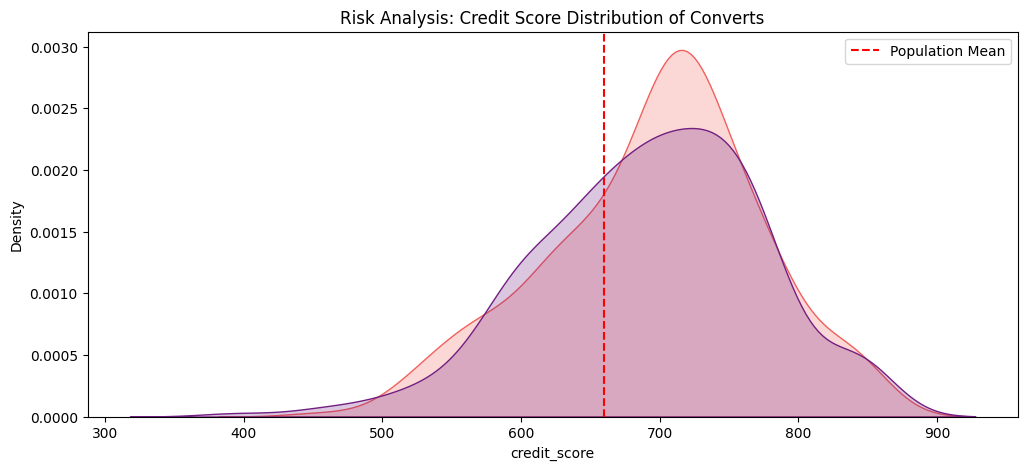

/databricks/python/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/databricks/python/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/databricks/python/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


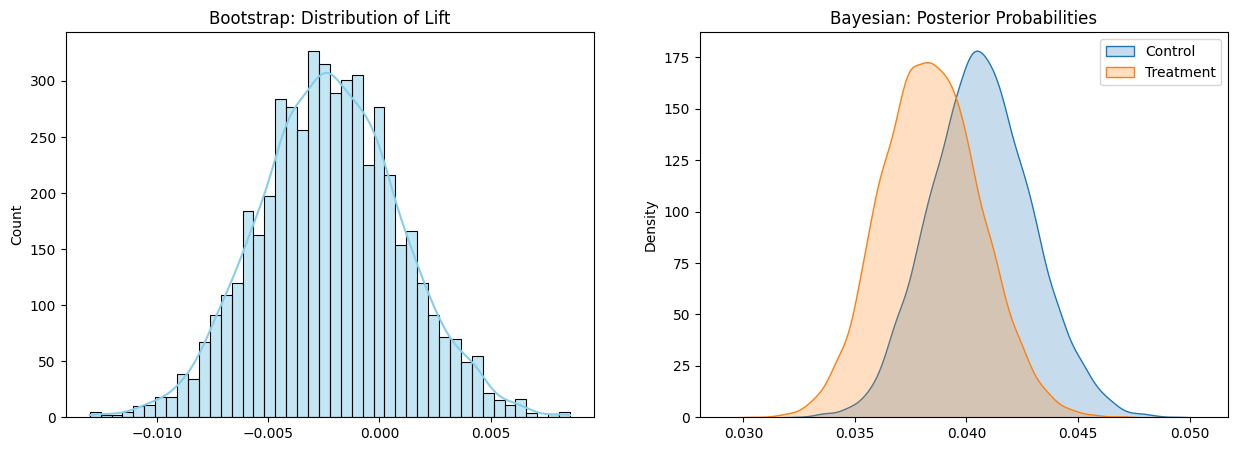

In [0]:
# Risk portfolio and Visulaization 

def plot_risk_profile(df):
    plt.figure(figsize=(12, 5))
    converters = df[df['converted'] == 1]
    sns.kdeplot(data=converters, x='credit_score', hue='group', fill=True, palette='magma')
    plt.title("Risk Analysis: Credit Score Distribution of Converts")
    plt.axvline(660, color='red', linestyle='--', label='Population Mean')
    plt.legend()
    plt.show()

def plot_stat_comparison(boot_res, bay_res):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.histplot(boot_res['samples'], kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title("Bootstrap: Distribution of Lift")
    sns.kdeplot(bay_res['samples_c'], label='Control', fill=True, ax=axes[1])
    sns.kdeplot(bay_res['samples_t'], label='Treatment', fill=True, ax=axes[1])
    axes[1].set_title("Bayesian: Posterior Probabilities")
    plt.legend()
    plt.show()

plot_risk_profile(df_banking)
plot_stat_comparison(boot_res, bay_res)

In [0]:
def display_experiment_results(z_res, boot_res, bay_res):
    print("="*50)
    print("A/B TEST RESULTS")
    print("="*50)
    
    # 1. Z-Test Results
    print(f"\n[1] FREQUENTIST Z-TEST")
    print(f"Z-Statistic: {z_res['stat']:.4f}")
    print(f"P-Value:     {z_res['p_value']:.4f}")
    status = "SIGNIFICANT" if z_res['p_value'] < 0.05 else "NOT SIGNIFICANT"
    print(f"Conclusion:  {status} (at alpha=0.05)")

    # 2. Bootstrap Results
    ci_low = np.percentile(boot_res['samples'], 2.5)
    ci_high = np.percentile(boot_res['samples'], 97.5)
    print(f"\n[2] BOOTSTRAP RESAMPLING (5000 iterations)")
    print(f"Estimated Lift: {np.mean(boot_res['samples']):.2%}")
    print(f"95% Conf Int:   [{ci_low:.4%}, {ci_high:.4%}]")
    print(f"P-Value:        {boot_res['p_value']:.4f}")

    # 3. Bayesian Results
    hdi_low = np.percentile(bay_res['samples_t'] - bay_res['samples_c'], 2.5)
    hdi_high = np.percentile(bay_res['samples_t'] - bay_res['samples_c'], 97.5)
    print(f"\n[3] BAYESIAN POSTERIOR ANALYSIS")
    print(f"P(Treatment > Control): {bay_res['prob_winner']:.2%}")
    print(f"95% Credible Interval:  [{hdi_low:.4%}, {hdi_high:.4%}]")
    
    # Risk Assessment (Expected Loss)
    # This is a very advanced metric: 'How much do I lose if I switch to B and I'm wrong?'
    loss = np.mean(np.maximum(0, bay_res['samples_c'] - bay_res['samples_t']))
    print(f"Expected Loss if B chosen: {loss:.6f}")
    print("="*50)

# Run the display
display_experiment_results(z_res, boot_res, bay_res)

A/B TEST RESULTS DASHBOARD

[1] FREQUENTIST Z-TEST
Z-Statistic: -0.7044
P-Value:     0.4812
Conclusion:  NOT SIGNIFICANT (at alpha=0.05)

[2] BOOTSTRAP RESAMPLING (5000 iterations)
Estimated Lift: -0.22%
95% Conf Int:   [-0.8370%, 0.4181%]
P-Value:        0.7606

[3] BAYESIAN POSTERIOR ANALYSIS
P(Treatment > Control): 23.57%
95% Credible Interval:  [-0.8471%, 0.3973%]
Expected Loss if B chosen: 0.002686


In [0]:
# results 
def display_results_and_final_call(z_res, boot_res, bay_res):
    print(f"\n[SUMMARY]")
    print(f"Z-Test P-Value: {z_res['p_value']:.4f}")
    print(f"Bayesian P(B>A): {bay_res['prob_winner']:.2%}")
    
    loss = np.mean(np.maximum(0, bay_res['samples_c'] - bay_res['samples_t']))
    print(f"Bayesian Expected Loss: {loss:.6f}")

    if z_res['p_value'] < 0.05 and bay_res['prob_winner'] > 0.95:
        call = "🚀 SHIP IT: High confidence global win."
    elif bay_res['prob_winner'] > 0.85:
        call = "📈 TARGETED ROLLOUT: Significant segment wins; deploy to Younger demographic."
    else:
        call = "🛑 STOP: No global advantage found."
    
    print(f"\nFINAL RECOMMENDATION: {call}")

display_results_and_final_call(z_res, boot_res, bay_res)


[SUMMARY]
Z-Test P-Value: 0.4812
Bayesian P(B>A): 23.57%
Bayesian Expected Loss: 0.002686

FINAL RECOMMENDATION: 🛑 STOP: No global advantage found.
